<a href="https://colab.research.google.com/github/sarahazizah142406-create/Tugas-PCD-tsara-azizah-effendhi/blob/main/PCD_tugas_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

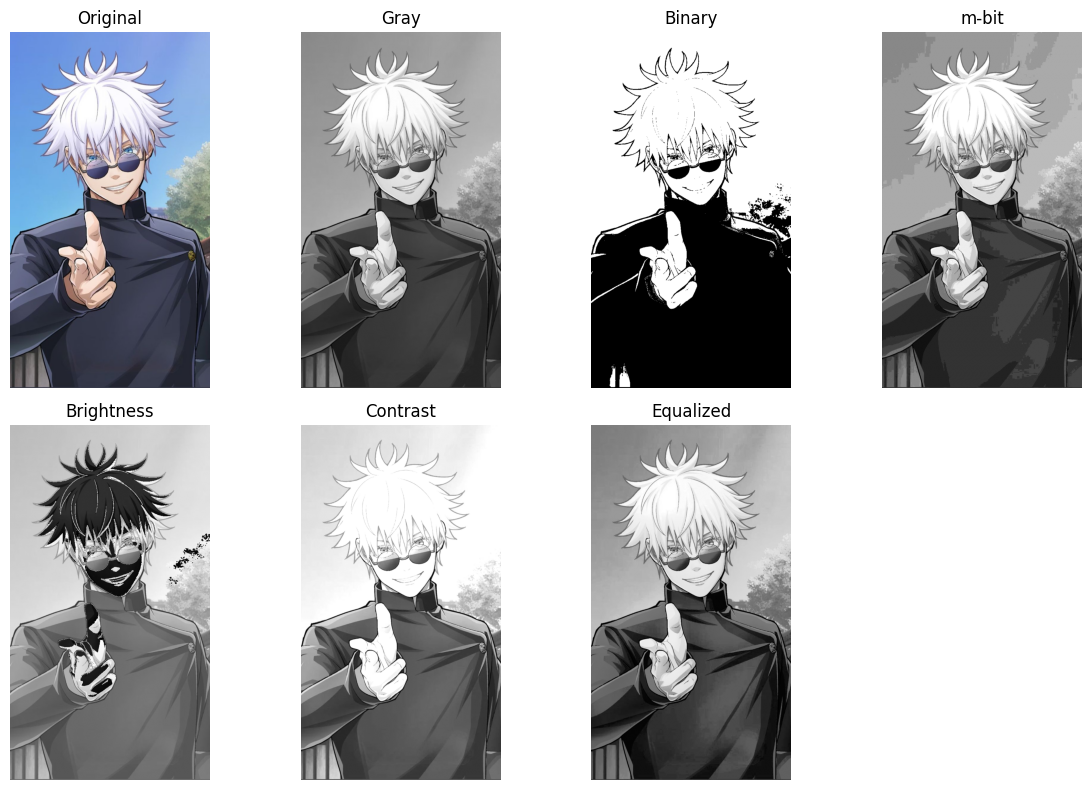

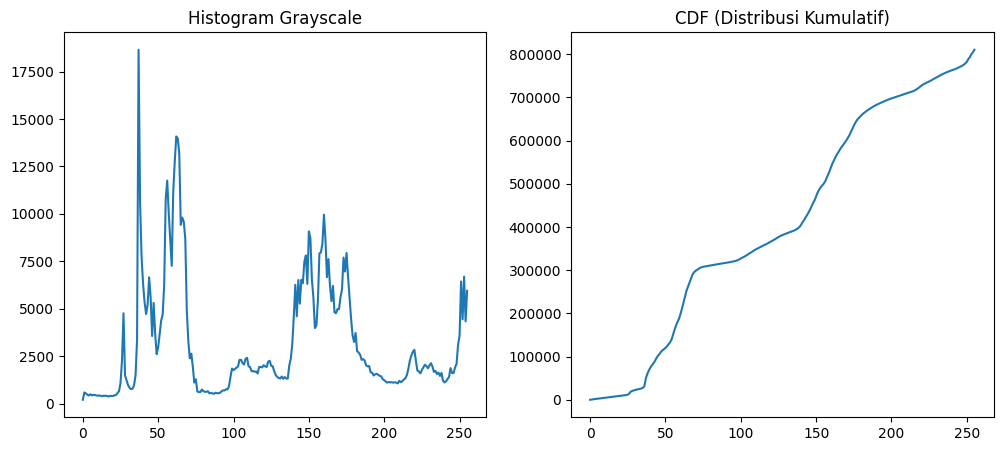

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD GAMBAR
# =========================
img = cv2.imread("/content/Gojo Satoru ★.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =========================
# 1. RGB → GRAYSCALE
# =========================
def rgb_to_gray(img):
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]
    gray = 0.299 * R + 0.587 * G + 0.114 * B
    return gray.astype(np.uint8)

gray = rgb_to_gray(img_rgb)

# =========================
# 2. GRAYSCALE → BINARY
# =========================
def gray_to_binary(gray, threshold=128):
    return np.where(gray > threshold, 255, 0).astype(np.uint8)

binary = gray_to_binary(gray)

# =========================
# 3. GRAYSCALE → M-BIT
# =========================
def gray_to_mbit(gray, m=4):
    levels = 2 ** m
    step = 256 // levels
    return ((gray // step) * step).astype(np.uint8)

mbit = gray_to_mbit(gray, m=4)

# =========================
# 4. BRIGHTNESS
# =========================
def adjust_brightness(img, value):
    return np.clip(img + value, 0, 255).astype(np.uint8)

bright = adjust_brightness(gray, 50)

# =========================
# 5. KONTRAS
# =========================
def adjust_contrast(img, alpha):
    return np.clip(img * alpha, 0, 255).astype(np.uint8)

contrast = adjust_contrast(gray, 1.5)

# =========================
# 6. HISTOGRAM
# =========================
def histogram(gray):
    hist = np.zeros(256)
    for pixel in gray.flatten():
        hist[pixel] += 1
    return hist

hist = histogram(gray)

# =========================
# 7. CDF (Distribusi Kumulatif)
# =========================
def cumulative_distribution(hist):
    return np.cumsum(hist)

cdf = cumulative_distribution(hist)

# =========================
# 8. HISTOGRAM EQUALIZATION (MANUAL)
# =========================
def histogram_equalization(gray):
    hist = histogram(gray)
    cdf = np.cumsum(hist)

    cdf_min = cdf[cdf > 0][0]
    total = gray.size

    cdf_norm = (cdf - cdf_min) / (total - cdf_min)
    cdf_norm = (cdf_norm * 255).astype(np.uint8)

    return cdf_norm[gray]

equalized = histogram_equalization(gray)

# =========================
# VISUALISASI GAMBAR
# =========================
titles = ["Original", "Gray", "Binary", "m-bit", "Brightness", "Contrast", "Equalized"]
images = [img_rgb, gray, binary, mbit, bright, contrast, equalized]

plt.figure(figsize=(12,8))
for i in range(len(images)):
    plt.subplot(2,4,i+1)
    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# VISUALISASI HISTOGRAM
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(hist)
plt.title("Histogram Grayscale")

plt.subplot(1,2,2)
plt.plot(cdf)
plt.title("CDF (Distribusi Kumulatif)")

plt.show()